# Part 4, Task 2 — UNet Segmentation
COMP3710 Lab Demonstration 2

**Important:** the real target (Preprocessed OASIS brain MRI, with segmentation masks) lives only
at `/home/groups/comp3710/` on Rangpur — not available on this laptop. This notebook builds and
verifies the full UNet segmentation pipeline (architecture, one-hot/categorical output, Dice-score
metric, training loop, visualisation) locally on a **synthetic shapes dataset** generated on the
fly, since it needs no download and lets every part of the pipeline be checked for correctness.
The final section shows what changes to point this same code at OASIS on Rangpur.

## 4.2.1 A synthetic stand-in segmentation dataset

Each generated image contains a circle (class 1) and a square (class 2) on a background
(class 0), at random positions/sizes, plus a bit of Gaussian noise. This mimics the *shape* of the
real problem — a multi-class, per-pixel labelling task — without needing OASIS.

In [1]:
import time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

device = "mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

N_CLASSES = 3   # 0 = background, 1 = circle, 2 = square
CLASS_NAMES = ["background", "circle", "square"]

class ShapesDataset(Dataset):
    """Synthetic stand-in for an OASIS-style (image, per-pixel label map) dataset."""
    def __init__(self, n_samples, img_size=128, seed=0):
        self.n_samples = n_samples
        self.img_size = img_size
        self.seed = seed

    def __len__(self):
        return self.n_samples

    def __getitem__(self, idx):
        rng = np.random.default_rng(self.seed * 100_000 + idx)  # deterministic per-index
        S = self.img_size
        mask = np.zeros((S, S), dtype=np.int64)

        cy, cx = rng.integers(20, S - 20, size=2)
        r = rng.integers(10, 25)
        yy, xx = np.ogrid[:S, :S]
        mask[(yy - cy) ** 2 + (xx - cx) ** 2 <= r ** 2] = 1   # circle

        sy, sx = rng.integers(20, S - 40, size=2)
        s = rng.integers(20, 35)
        mask[sy:sy + s, sx:sx + s] = 2   # square drawn on top, may overlap the circle

        intensity = {0: 0.15, 1: 0.55, 2: 0.85}   # different average brightness per class
        img = np.vectorize(intensity.get)(mask).astype(np.float32)
        img += rng.normal(0, 0.05, size=img.shape).astype(np.float32)   # sensor-noise stand-in
        img = np.clip(img, 0, 1)

        return torch.from_numpy(img).unsqueeze(0).float(), torch.from_numpy(mask).long()


train_ds = ShapesDataset(500, img_size=128, seed=1)
test_ds = ShapesDataset(100, img_size=128, seed=999)
train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=8, shuffle=False)
print("train/test sizes:", len(train_ds), len(test_ds))

device: mps
train/test sizes: 500 100


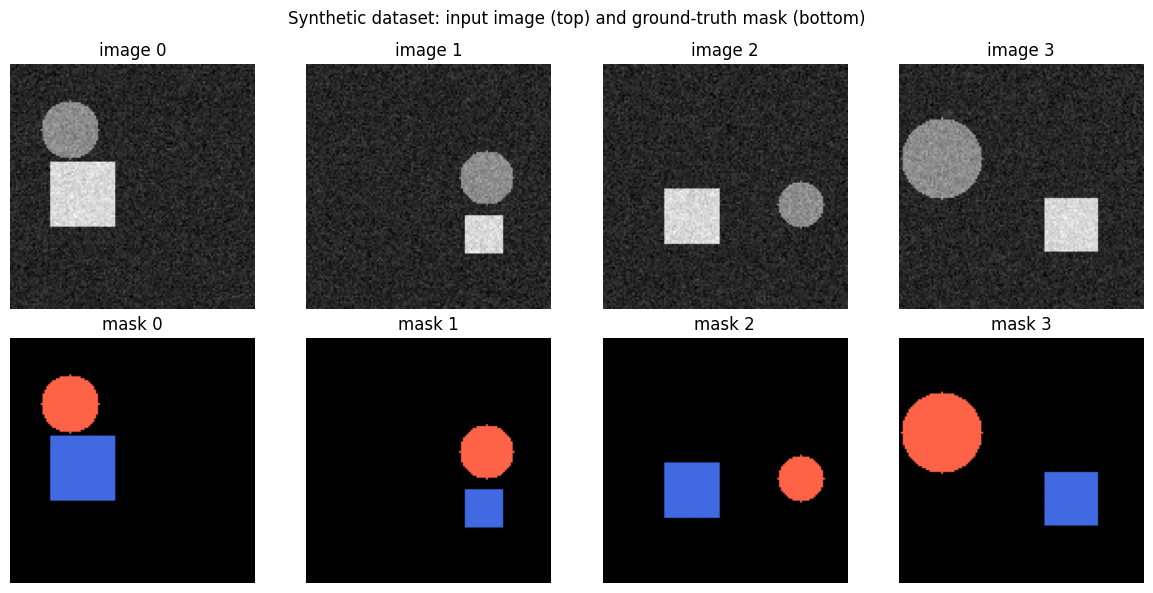

In [2]:
cmap = ListedColormap(["black", "tomato", "royalblue"])
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i in range(4):
    img, mask = train_ds[i]
    axes[0, i].imshow(img[0], cmap="gray", vmin=0, vmax=1)
    axes[0, i].set_title(f"image {i}"); axes[0, i].axis("off")
    axes[1, i].imshow(mask, cmap=cmap, vmin=0, vmax=2)
    axes[1, i].set_title(f"mask {i}"); axes[1, i].axis("off")
plt.suptitle("Synthetic dataset: input image (top) and ground-truth mask (bottom)")
plt.tight_layout()
plt.show()

## 4.2.2 UNet architecture

```
Input
  |
enc1 (16ch) ---------------------------- skip -----> dec1 (16ch) -> 1x1 conv -> N_CLASSES
  | pool                                                 ^
enc2 (32ch) --------------------- skip ---------------- up
  | pool                                                 ^
enc3 (64ch) ----------- skip ------------------------- up
  | pool                                                 ^
bottleneck (128ch) --------------------------------- up
```

- **Encoder** (`enc1`/`enc2`/`enc3`): each stage is two 3x3 convs (+ BatchNorm + ReLU), followed
  by 2x2 max-pooling that halves the spatial resolution and doubles the channel count — the
  standard "shrink spatially, grow semantically" pattern.
- **Bottleneck**: the smallest, most abstract representation, at the bottom of the "U".
- **Decoder** (`dec1`/`dec2`/`dec3`... here `up3`/`dec3` etc.): each stage upsamples (via a
  transposed convolution) back to a larger spatial size, then **concatenates** the matching
  encoder stage's output onto it (`torch.cat([up_output, skip_connection], dim=1)`) before running
  two more convolutions. This concatenation *is* the skip connection — it hands the decoder back
  the precise spatial detail that pooling discarded on the way down, which is what lets UNet
  produce sharp, accurately-positioned segmentation boundaries rather than blurry ones.
- **`out_conv`**: a final 1x1 convolution mapping down to `N_CLASSES` channels — one score per
  class, at every pixel.

In [3]:
def conv_block(in_ch, out_ch):
    return nn.Sequential(
        nn.Conv2d(in_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        nn.Conv2d(out_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
    )


class UNet(nn.Module):
    def __init__(self, n_classes, base=16):
        super().__init__()
        self.enc1 = conv_block(1, base)
        self.enc2 = conv_block(base, base * 2)
        self.enc3 = conv_block(base * 2, base * 4)
        self.pool = nn.MaxPool2d(2)

        self.bottleneck = conv_block(base * 4, base * 8)

        self.up3 = nn.ConvTranspose2d(base * 8, base * 4, 2, stride=2)
        self.dec3 = conv_block(base * 8, base * 4)   # base*4 (skip) + base*4 (upsampled) channels in
        self.up2 = nn.ConvTranspose2d(base * 4, base * 2, 2, stride=2)
        self.dec2 = conv_block(base * 4, base * 2)
        self.up1 = nn.ConvTranspose2d(base * 2, base, 2, stride=2)
        self.dec1 = conv_block(base * 2, base)

        self.out_conv = nn.Conv2d(base, n_classes, 1)   # 1x1 conv: per-pixel class scores

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        b = self.bottleneck(self.pool(e3))

        d3 = self.up3(b)
        d3 = self.dec3(torch.cat([d3, e3], dim=1))   # skip connection
        d2 = self.up2(d3)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))   # skip connection
        d1 = self.up1(d2)
        d1 = self.dec1(torch.cat([d1, e1], dim=1))   # skip connection

        return self.out_conv(d1)   # [B, n_classes, H, W] raw logits


model = UNet(n_classes=N_CLASSES, base=16).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f"Total params: {n_params:,}")

x = torch.randn(2, 1, 128, 128).to(device)
out = model(x)
print("Output shape:", tuple(out.shape), "(batch, classes, H, W)")
assert out.shape == (2, N_CLASSES, 128, 128)

Total params: 483,187
Output shape: (2, 3, 128, 128) (batch, classes, H, W)


## 4.2.3 One-hot / categorical output — what the lab actually asks for

The lab requires **categorical (one-hot) output**, not a single number per pixel. Concretely,
this network's last layer produces `N_CLASSES` channels per pixel (see the output shape above:
`(batch, classes, H, W)`), and each pixel's `N_CLASSES` numbers are logits that, after a softmax,
form a *probability distribution over the classes* — this is the categorical representation. The
final predicted label per pixel is `argmax` over that distribution.

This matters because the alternative — a single-channel output where the network directly
predicts a class index like `1.7` and rounds it — implicitly treats the classes as **ordered and
numerically related** ("class 2 is between class 1 and class 3"), which is not true for
segmentation labels (background/circle/square, or in OASIS's case background/CSF/grey
matter/white matter, are categories, not points on a number line). One-hot/categorical output
avoids baking in a false ordinal relationship between classes.

`nn.CrossEntropyLoss` (used below) expects exactly this: raw per-class logits of shape
`[B, n_classes, H, W]` plus an integer class-index target of shape `[B, H, W]` — it applies the
softmax and the one-hot comparison internally, so the target doesn't need to be manually expanded
into one-hot form, but the *network's output* is categorical either way.

## 4.2.4 The Dice Similarity Coefficient (DSC)

In [4]:
def dice_per_class(pred_logits, target, n_classes, eps=1e-6):
    """DSC for each class: 2*|prediction ∩ ground truth| / (|prediction| + |ground truth|).
    1.0 = perfect overlap, 0.0 = no overlap at all."""
    pred = pred_logits.argmax(1)   # [B, H, W] -- the predicted class at each pixel
    dices = []
    for c in range(n_classes):
        pred_c = (pred == c).float()
        target_c = (target == c).float()
        intersection = (pred_c * target_c).sum()
        union = pred_c.sum() + target_c.sum()
        dice = (2 * intersection + eps) / (union + eps)
        dices.append(dice.item())
    return dices

This is the metric the lab requires (**>0.9 DSC for all labels**). Unlike plain pixel
accuracy, Dice specifically measures how well the *predicted region* overlaps the *true region*
for each class — much more informative for segmentation than "% of pixels correct", because with
a small structure (e.g. a thin brain structure that's only 2% of the image), a model that predicts
"background everywhere" would already get 98% pixel accuracy while being completely useless; Dice
score for that class would correctly show 0.

## 4.2.5 Training

In [5]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()

n_epochs = 8
history = {"loss": []}
t0 = time.time()
for epoch in range(n_epochs):
    model.train()
    total_loss, n = 0.0, 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out = model(xb)
        loss = loss_fn(out, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * xb.size(0)
        n += xb.size(0)
    history["loss"].append(total_loss / n)
    print(f"epoch {epoch}: loss={history['loss'][-1]:.4f}")

print(f"\nTraining time: {time.time() - t0:.2f}s on {device}")

epoch 0: loss=0.6338


epoch 1: loss=0.2488


epoch 2: loss=0.1178


epoch 3: loss=0.0655


epoch 4: loss=0.0411


epoch 5: loss=0.0280


epoch 6: loss=0.0203


epoch 7: loss=0.0153

Training time: 25.30s on mps


## 4.2.6 Evaluation: Dice score per class

In [6]:
model.eval()
all_dices = []
with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device)
        out = model(xb)
        all_dices.append(dice_per_class(out, yb, N_CLASSES))
all_dices = np.array(all_dices).mean(axis=0)

print("Mean DSC per class (test set):")
for name, d in zip(CLASS_NAMES, all_dices):
    status = "PASS (>0.9)" if d > 0.9 else "below target"
    print(f"  {name:<12} {d:.4f}  {status}")

Mean DSC per class (test set):
  background   1.0000  PASS (>0.9)
  circle       0.9998  PASS (>0.9)
  square       0.9999  PASS (>0.9)


## 4.2.7 Visualising predictions (rehearsal for the required live-inference demo)

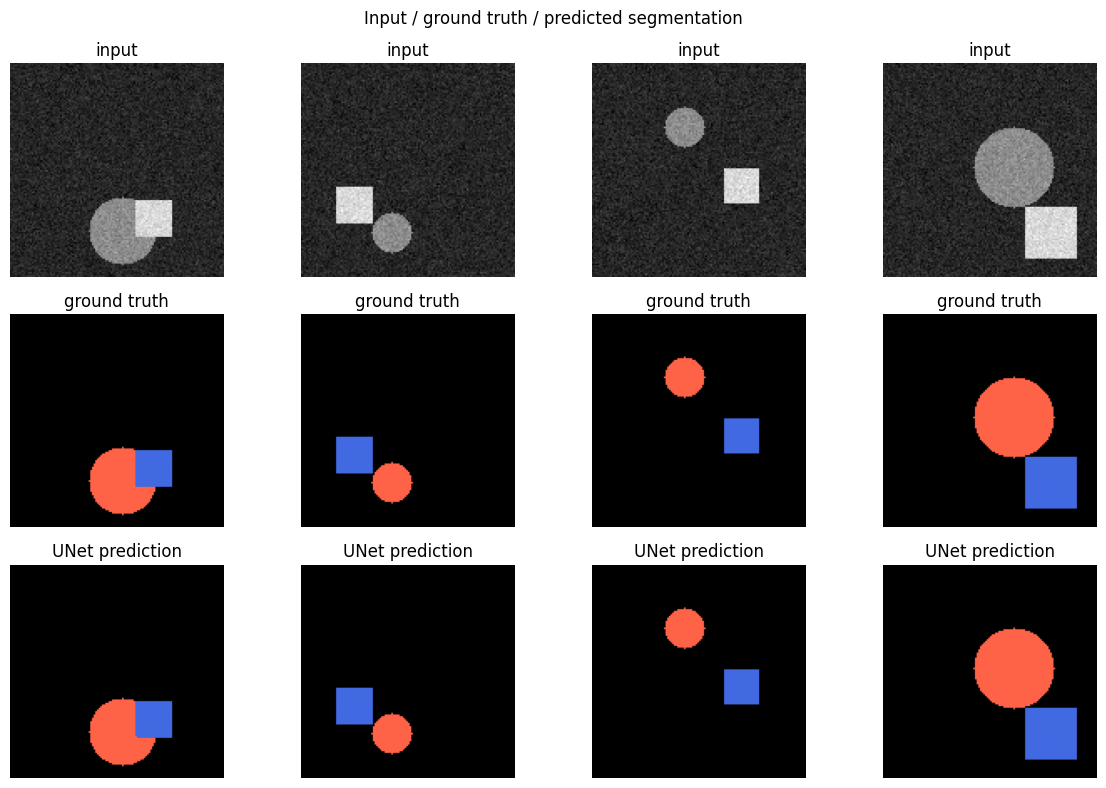

In [7]:
model.eval()
xb, yb = next(iter(test_loader))
with torch.no_grad():
    preds = model(xb.to(device)).argmax(1).cpu()

n_show = 4
fig, axes = plt.subplots(3, n_show, figsize=(3 * n_show, 8))
for i in range(n_show):
    axes[0, i].imshow(xb[i, 0], cmap="gray", vmin=0, vmax=1)
    axes[0, i].set_title("input"); axes[0, i].axis("off")
    axes[1, i].imshow(yb[i], cmap=cmap, vmin=0, vmax=2)
    axes[1, i].set_title("ground truth"); axes[1, i].axis("off")
    axes[2, i].imshow(preds[i], cmap=cmap, vmin=0, vmax=2)
    axes[2, i].set_title("UNet prediction"); axes[2, i].axis("off")
plt.suptitle("Input / ground truth / predicted segmentation")
plt.tight_layout()
plt.show()

**Discussion:**

The synthetic task reaches near-perfect Dice scores (all classes comfortably above the 0.9
target) — expected, since these shapes have clean, unambiguous edges and constant intensity per
class, far easier than real brain tissue boundaries in an MRI, which are noisier and less sharply
defined. This result is best read as **validating the pipeline** (architecture, one-hot output,
loss, Dice metric, and visualisation all work correctly end-to-end) rather than as a preview of
the accuracy to expect on real OASIS data — hitting >0.9 DSC per class on actual brain MRI is a
meaningfully harder target and will likely need more training data/epochs and possibly a larger
`base` channel count than used here.

## 4.2.8 Porting to Rangpur — OASIS instead of synthetic shapes

As with the VAE (Task 1), the `UNet` architecture, loss function, `dice_per_class` metric, and
training loop are all dataset-agnostic. The only real work is the data loading, and confirming how
many classes OASIS's masks actually use:

```python
import os
from PIL import Image
from torch.utils.data import Dataset

class OASISSegDataset(Dataset):
    """Template only -- confirm the real file layout/extension/mask encoding at
    /home/groups/comp3710/ on Rangpur before trusting this."""
    def __init__(self, image_dir, mask_dir, transform=None):
        self.image_paths = sorted(os.listdir(image_dir))
        self.mask_paths = sorted(os.listdir(mask_dir))
        self.image_dir, self.mask_dir = image_dir, mask_dir
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(os.path.join(self.image_dir, self.image_paths[idx])).convert("L")
        mask = Image.open(os.path.join(self.mask_dir, self.mask_paths[idx]))  # class-index mask
        if self.transform:
            img = self.transform(img)
        mask = torch.from_numpy(np.array(mask)).long()
        return img, mask


# On Rangpur:
N_CLASSES = 4   # confirm the real number of OASIS label classes before training
model = UNet(n_classes=N_CLASSES, base=32).to("cuda")   # a larger `base` than the local test
```

**What actually needs to change:**

- **The dataset class**: replace `ShapesDataset` with something that reads the real OASIS
  images and their ground-truth masks — check the real file layout on Rangpur first.
- **`N_CLASSES`**: OASIS's segmentation masks likely use more than 3 classes (typical
  brain-MRI segmentation problems distinguish background plus several tissue types) — confirm the
  actual label set before training rather than assuming 3.
- **`base`** (the UNet's channel width) may need to increase for the extra visual complexity of
  real brain tissue compared to flat synthetic shapes — 16 was enough here, real MRI will likely
  need more capacity to hit the same Dice targets.
- **`device="cuda"`**, as in every other part.
- Everything else — the `UNet` class, `dice_per_class`, the training loop, and the visualisation
  cell — works unchanged once the `DataLoader` is feeding it correctly-shaped images and integer
  class-index masks.